###### 1. Connectivity 

In [ ]:
To test the connectivity of the servers under the webserver’s group, 
run the ansible ping command as shown. 

Here ping is a module which performs a particular function to 
test whether the hosts can be connected as defined in the inventory file or not. 

$ ansible –m ping all

$ ansible –m ping webservers

###### 2. List the Hosts

In [ ]:
To list the hosts in the inventory file, you can run the below command

$ ansible webservers --list-hosts

###### Ansible Usage

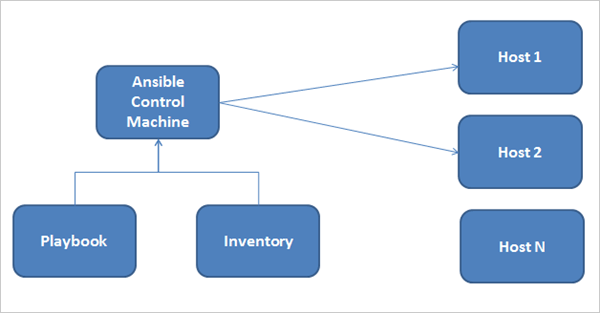

In [ ]:
Ansible consist of 3 main components :- 

1. Control Machine
2. Inventory
3. Playbook

The control machine manages the execution of the Playbook. 
It can be installed on your laptop or on any machine on the internet.

The Inventory file provides a complete list of all the target machines
on which various modules are run by doing an ssh connection and install the necessary software’s.

The playbook consists of steps that the control mechanism will perform on the servers defined in the inventory file.

Very important to understand here is that Ansible interacts with all the servers defined 
in the inventory through the SSH protocol which is a secure method of remote login.
Every operation is done and file transfer is encrypted.

###### Ansible Modules

In [ ]:
Modules are the main building blocks of Ansible and are basically reusable scripts 
that are used by Ansible playbooks. 

Ansible comes with a number of reusable modules. 

These include functionality for controlling services, software package installation,
working with files and directories etc.

The syntax is as follows while running the ad-hoc commands 
which help in running single or simple tasks just once and
which need not be run later. 

For E.g. just installing Tomcat on all servers.

ansible hostORgroup -m module_name -a "arguments" -u username --become

###### 1) Setup Module

In [ ]:
To get information about the network or hardware or OS version or memory related information,
the setup module will help to gather the same about the target machines.

On the control, the machine runs the below command.

$ ansible webservers –m setup

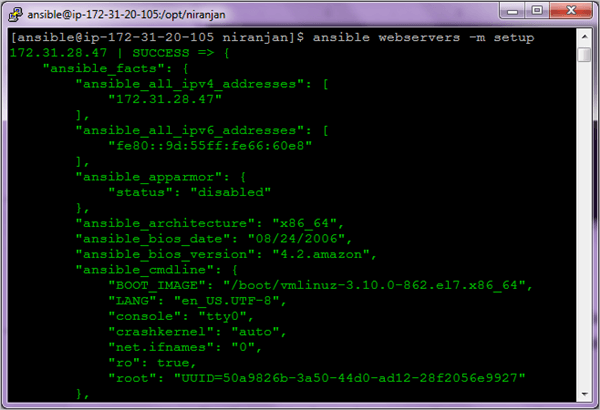

###### 2) Command Module

In [ ]:
The command module simply executes a specific command on the target machine and gives the output.

Some of the Examples are given below:- 

$ ansible webservers –m command - a 'uptime'

$ ansible webservers –m command –a 'hostname'

###### 3) User Module

In [ ]:
Using this module, one can create or delete users.

To add user :- 
------------
$ ansible webservers -m user -a 'name=user1 password=user1' --become

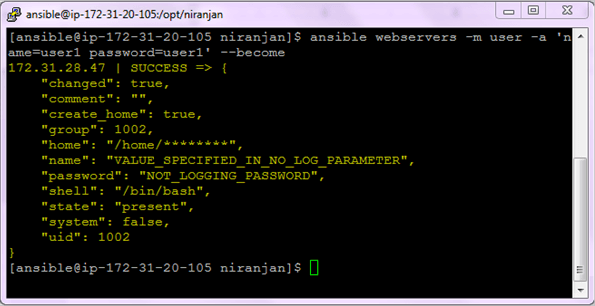 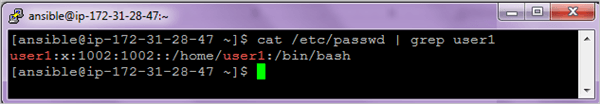

In [ ]:
To delete user :- 
--------------
$ ansible webservers -m user -a 'name=user1 state=absent' --become

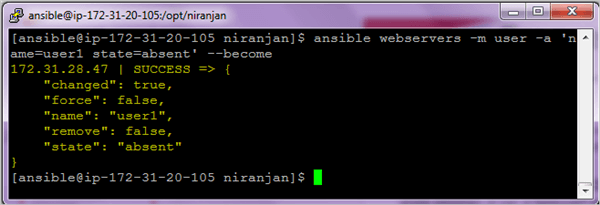 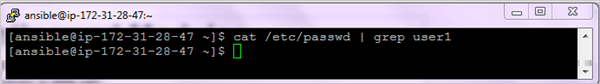

In [ ]:
Options:
-------

become – Privilege to the superuser to run the command

state = absent to delete the user

###### 4) File Module

In [ ]:
This module is used to create files, directories, set, or change file permissions and ownership etc

Example 1: Create a file
-------------------------

$ ansible webservers -m file -a 'dest=/home/ansible/file1.txt state=touch mode=600 owner=ansadmin group=ansadmin'


Example 2: Delete a file
-------------------------

$ ansible webservers -m file -a "dest=/home/ansible/file1.txt state=absent"


Example 3: Create a directory
------------------------------

To create a directory using the file module, we need to set two parameters.

 - Path(alias – name, dest) – This is the absolute path of the directory to be created.
    
 - State – You should enter the value as ‘directory.’ By default, the value is ‘file’.

$ ansible webservers -m file -a "dest=/home/ansible/ansdir state=directory mode=755"


Example 4: Delete a directory
-----------------------------

We can delete a directory by setting the state parameter value to absent. 
The directory and all its contents will be deleted.

$ ansible webservers -m file -a "dest=/home/ansible/ansdir state=absent"

Example 5: Create a file using Cat command
------------------------------------------
On the machines under webservers group,check for the file created using below given command and
run the command to view the text file.

$ ansible webservers –m command -a 'cat temp.txt'

$ ansible webservers -m command -a 'ls -l > temp.txt'

###### 5) Copy Module

In [ ]:
It is used for copying files to multiple target machines.

$ ansible webservers -m copy -a "src=sample.txt dest=/home/ansible/sample.txt"

###### 7) Managing Software Packages

In [ ]:
If we need to install software packages through ‘yum’ or ‘apt’ you can use the below commands.

Example 1: Install GIT
-----------------------

$ ansible webservers –m yum -a "name=git state=present" --become

In this command, state=present will check if the package is installed or not 
and if not installed it will install the latest version.

Example 2: Check if the package is installed & update it to the latest version.
-------------------------------------------------------------------------------

$ ansible webservers -m yum -a "name=git state=latest"

In the above command, state=latest will update the package to the latest version only.

Example 3: Install Apache Webserver
------------------------------------

$ ansible webservers -m yum -a "name=httpd state=present" –become

Example 4: Check if Maven is installed or not.
----------------------------------------------

$ ansible webservers -m yum -a "name=maven state=absent" –become

###### 8) Managing Services Module

In [ ]:
To manage services with ansible, we use a module ‘service’.

Starting a service

$ ansible webservers -m service -a “name=httpd state=started” --become

Stopping a service

$ ansible webservers -m service -a “name=httpd state=stopped” --become

Restarting a service

$ ansible webservers -m service -a “name=httpd state=restarted --become

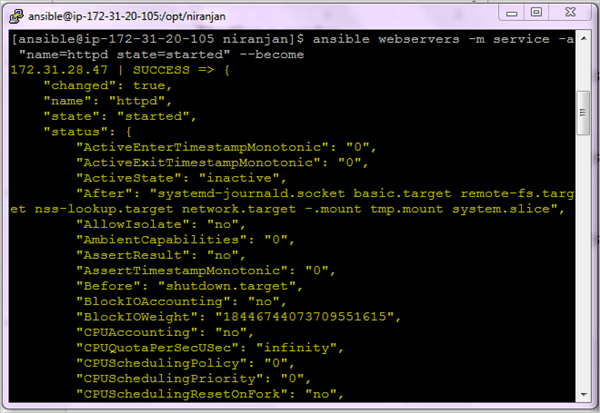  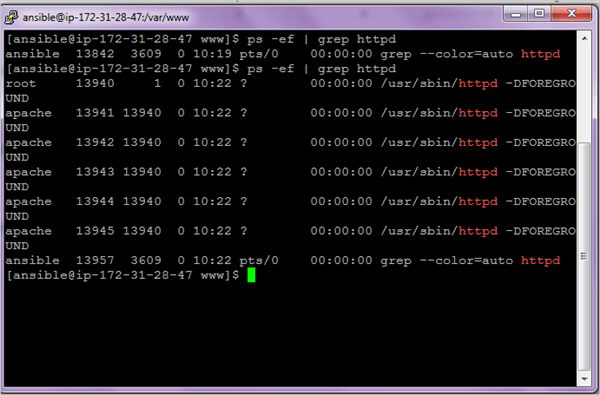

https://www.softwaretestinghelp.com/ansible-tutorial-1/